# Iris Species Classification

This project analyzes the Iris dataset with a Decision Tree classifier trained with the entropy criterion. The notebook follows a compact machine learning workflow: data inspection, data quality checks, exploratory analysis, model validation, tree diagnostics, decision-path inspection, pruning diagnostics, and entropy-based interpretation.

The goal is not to maximize benchmark performance on a small, well-known dataset. The goal is to show whether the model behavior is consistent with the data structure and to explain where the classifier is reliable versus where class overlap creates errors.

## 1. Environment and Reproducibility

This section defines the computational environment and the reproducibility settings used throughout the notebook. Reproducibility is important because the train/test split, cross-validation procedure, t-SNE projection, and permutation importance analysis all involve stochastic or order-sensitive operations.

### Library Imports

In [1]:
# Optional local dependency installation
# %pip install -r requirements.txt -q

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
import scipy
from scipy.stats import entropy

# Dataset
from sklearn.datasets import load_iris

# Dimensionality reduction
from sklearn.manifold import TSNE

# Model inspection
from sklearn.inspection import permutation_importance

# Model selection and validation
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model and visualization
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

# Library version tracking
import sklearn

The required libraries are imported and grouped by purpose. This organization makes the notebook dependencies easier to audit and helps distinguish data manipulation, visualization, modeling, validation, and interpretability tools.

### Reproducibility Configuration

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5
N_PERMUTATION_REPEATS = 30

np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
})

A single random seed is reused across stochastic steps, including the train/test split, cross-validation shuffling, t-SNE, and permutation importance. Shared configuration values are defined once so later cells do not silently diverge in their validation or visualization settings.

## 2. Data Loading

### Load the Iris Dataset

In [3]:
iris = load_iris()

FEATURE_COLUMNS = list(iris.feature_names)
CLASS_NAMES = list(iris.target_names)
SPECIES_MAP = dict(enumerate(CLASS_NAMES))
CLASS_PALETTE = {
    "setosa": "#4C78A8",
    "versicolor": "#F58518",
    "virginica": "#54A24B",
}

iris_df = pd.DataFrame(iris.data, columns=FEATURE_COLUMNS)
iris_df["target"] = iris.target

The Iris dataset is loaded directly from scikit-learn and converted to a pandas DataFrame. Feature names, class names, class-label mappings, and the plotting palette are derived from the dataset metadata so later cells do not rely on repeated hard-coded labels.

### Initial Data Inspection

In [4]:
iris_shape = pd.DataFrame({
    "rows": [iris_df.shape[0]],
    "columns": [iris_df.shape[1]],
})

display(iris_shape)

,rows,columns
0,150,5


The dataset contains 150 observations and 5 columns. Four columns correspond to numerical flower measurements, while the target column stores the encoded species label. This confirms the expected size and structure before deeper inspection.

In [5]:
display(iris_df.head())
display(iris_df.tail())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


The first and last records confirm the expected ordering of the source dataset: Setosa examples appear at the beginning and Virginica examples at the end. This ordering is useful to know because later modeling steps must shuffle and stratify the data rather than relying on the raw row order.

### Descriptive Statistics

In [6]:
display(iris_df.drop(columns=["target"]).describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The descriptive statistics show that all four numerical features contain 150 valid observations, confirming that there are no missing values in the measurement columns at this stage.

Sepal length has a mean of 5.84 cm and ranges from 4.30 cm to 7.90 cm, while sepal width has a mean of 3.06 cm and ranges from 2.00 cm to 4.40 cm. These two variables show relatively moderate dispersion, with standard deviations of 0.83 and 0.44, respectively.

Petal length shows the largest absolute variation among the four features, with values ranging from 1.00 cm to 6.90 cm and a standard deviation of 1.77. Petal width ranges from 0.10 cm to 2.50 cm, with a standard deviation of 0.76. Although petal width does not have the largest absolute standard deviation, its variation is large relative to its mean.

These statistics suggest that petal-related measurements, especially petal length, may provide stronger discriminatory information for separating Iris species. This expectation will be examined visually in the exploratory analysis and later tested through the Decision Tree model.

## 3. Exploratory Data Analysis (EDA)

### Univariate Analysis

#### One-Dimensional Scatter Plot by Class

This analysis compares the distribution of each numerical feature across the three Iris species. Before plotting the one-dimensional scatter plots, a summary table is created to show the minimum, maximum, mean, and range of each feature by species. This makes the visual interpretation more grounded in numerical evidence.

sepal length (cm)                  sepal width (cm)             \
                         min  max  mean range              min  max  mean   
species                                                                     
setosa                   4.3  5.8  5.01   1.5              2.3  4.4  3.43   
versicolor               4.9  7.0  5.94   2.1              2.0  3.4  2.77   
virginica                4.9  7.9  6.59   3.0              2.2  3.8  2.97   

                 petal length (cm)                  petal width (cm)       \
           range               min  max  mean range              min  max   
species                                                                     
setosa       2.1               1.0  1.9  1.46   0.9              0.1  0.6   
versicolor   1.4               3.0  5.1  4.26   2.1              1.0  1.8   
virginica    1.6               4.5  6.9  5.55   2.4              1.4  2.5   

                        
            mean range  
species                 
setosa      0.25   0.5  
versicolor  1.33   0.8  
virginica   2.03   1.1

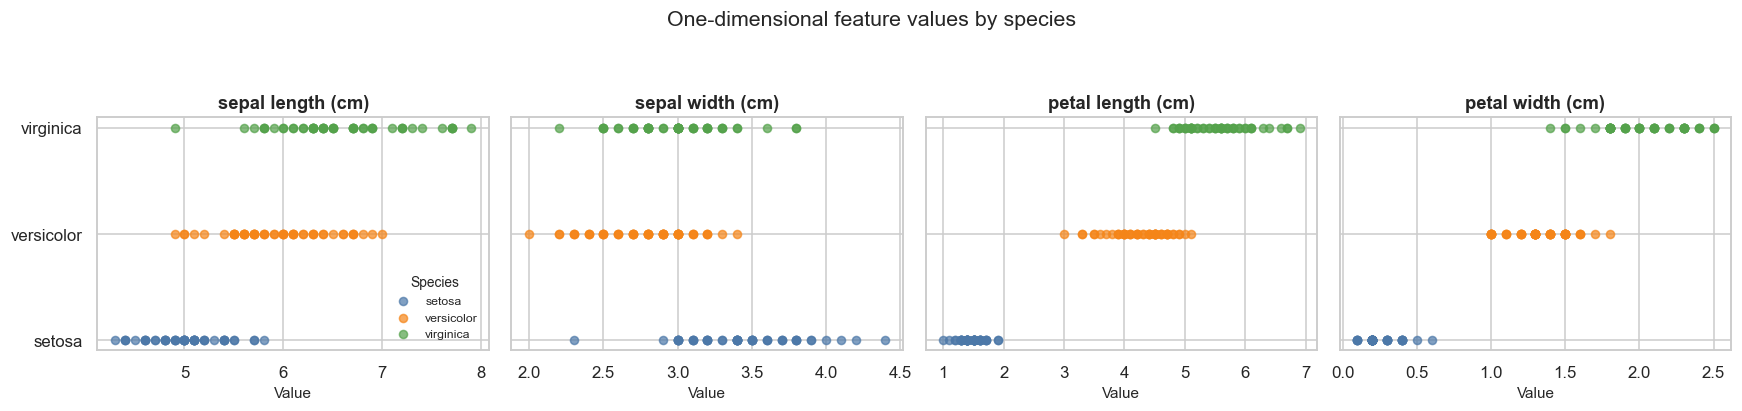

In [7]:
def make_plot_df(features_df, target, species_map=SPECIES_MAP):
    """Return a plotting copy with readable species labels."""
    plot_df = features_df.copy()
    plot_df["species"] = pd.Series(target, index=features_df.index).map(species_map)
    return plot_df


def summarize_features_by_species(features_df, target, species_map=SPECIES_MAP):
    """Create a summary table with min, max, mean, and range by species."""
    plot_df = make_plot_df(features_df, target, species_map)

    summary_df = (
        plot_df
        .groupby("species")[features_df.columns]
        .agg(["min", "max", "mean"])
        .round(2)
    )

    # Add range for each feature
    for feature in features_df.columns:
        summary_df[(feature, "range")] = (
            summary_df[(feature, "max")] - summary_df[(feature, "min")]
        ).round(2)

    # Reorder columns: min, max, mean, range for each feature
    ordered_columns = []
    for feature in features_df.columns:
        ordered_columns.extend([
            (feature, "min"),
            (feature, "max"),
            (feature, "mean"),
            (feature, "range")
        ])

    summary_df = summary_df[ordered_columns]

    return summary_df


def plot_1d_scatter_by_class(
    features_df,
    target,
    class_names=CLASS_NAMES,
    palette=CLASS_PALETTE,
):
    plot_df = make_plot_df(features_df, target)
    n_features = len(features_df.columns)

    fig, axes = plt.subplots(
        1,
        n_features,
        figsize=(4 * n_features, 3.8),
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for axis, feature in zip(axes, features_df.columns):
        for species_index, species in enumerate(class_names):
            species_values = plot_df.loc[plot_df["species"] == species, feature]

            axis.scatter(
                species_values,
                np.full(len(species_values), species_index),
                color=palette[species],
                label=species,
                s=28,
                alpha=0.70,
            )

        axis.set_title(feature)
        axis.set_xlabel("Value")
        axis.set_yticks(range(len(class_names)))

    axes[0].set_yticklabels(class_names)

    for axis in axes[1:]:
        axis.tick_params(axis="y", labelleft=False)

    axes[0].legend(
        title="Species",
        fontsize=8,
        title_fontsize=9,
        frameon=False
    )

    fig.suptitle("One-dimensional feature values by species", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


feature_summary_by_species = summarize_features_by_species(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

display(feature_summary_by_species)

plot_1d_scatter_by_class(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

The summary table and the one-dimensional scatter plots show that Setosa is clearly separated from the other species by petal measurements. Setosa has petal length values between 1.00 cm and 1.90 cm and petal width values between 0.10 cm and 0.60 cm, while Versicolor starts at 3.00 cm for petal length and 1.00 cm for petal width. This creates a visible gap between Setosa and the two other species in both petal-related variables.

The separation between Versicolor and Virginica is less clear. Versicolor has petal length values from 3.00 cm to 5.10 cm, while Virginica ranges from 4.50 cm to 6.90 cm. Therefore, the interval between 4.50 cm and 5.10 cm represents an overlap region between these two species. A similar pattern appears in petal width, where Versicolor ranges from 1.00 cm to 1.80 cm and Virginica ranges from 1.40 cm to 2.50 cm.

The sepal measurements show weaker class separation. Sepal length and sepal width present more overlap across the three species, making them less visually discriminative when analyzed individually. Based on both the printed summary and the scatter plots, petal length and petal width are expected to be more informative for the Decision Tree model, while most classification difficulty should occur between Versicolor and Virginica.

#### Boxplots by Variable and Species

Boxplots are used to compare the distribution of each feature across Iris species using robust summary statistics. Before plotting, the quartiles, median, interquartile range, and potential outlier counts are calculated for each feature and species. This helps interpret the visual patterns using numerical evidence rather than relying only on the plot.

In [8]:
def summarize_boxplot_statistics(features_df, target, species_map=SPECIES_MAP):
    """Create boxplot-oriented summary statistics by species and feature."""
    plot_df = make_plot_df(features_df, target, species_map)

    summary_rows = []

    for species in CLASS_NAMES:
        species_df = plot_df[plot_df["species"] == species]

        for feature in features_df.columns:
            values = species_df[feature]

            q1 = values.quantile(0.25)
            median = values.median()
            q3 = values.quantile(0.75)
            iqr = q3 - q1

            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outlier_count = (
                (values < lower_bound) | (values > upper_bound)
            ).sum()

            summary_rows.append({
                "species": species,
                "feature": feature,
                "min": values.min(),
                "q1": q1,
                "median": median,
                "q3": q3,
                "max": values.max(),
                "iqr": iqr,
                "potential_outliers": outlier_count
            })

    return pd.DataFrame(summary_rows)


boxplot_summary_df = summarize_boxplot_statistics(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

display(boxplot_summary_df.round(2))

,species,feature,min,q1,median,q3,max,iqr,potential_outliers
0,setosa,sepal length (cm),4.3,4.80,5.00,5.20,5.8,0.40,0
1,setosa,sepal width (cm),2.3,3.20,3.40,3.68,4.4,0.48,2
2,setosa,petal length (cm),1.0,1.40,1.50,1.58,1.9,0.18,4
3,setosa,petal width (cm),0.1,0.20,0.20,0.30,0.6,0.10,2
4,versicolor,sepal length (cm),4.9,5.60,5.90,6.30,7.0,0.70,0
5,versicolor,sepal width (cm),2.0,2.52,2.80,3.00,3.4,0.48,0
6,versicolor,petal length (cm),3.0,4.00,4.35,4.60,5.1,0.60,1
7,versicolor,petal width (cm),1.0,1.20,1.30,1.50,1.8,0.30,0
8,virginica,sepal length (cm),4.9,6.22,6.50,6.90,7.9,0.68,1
9,virginica,sepal width (cm),2.2,2.80,3.00,3.18,3.8,0.38,3


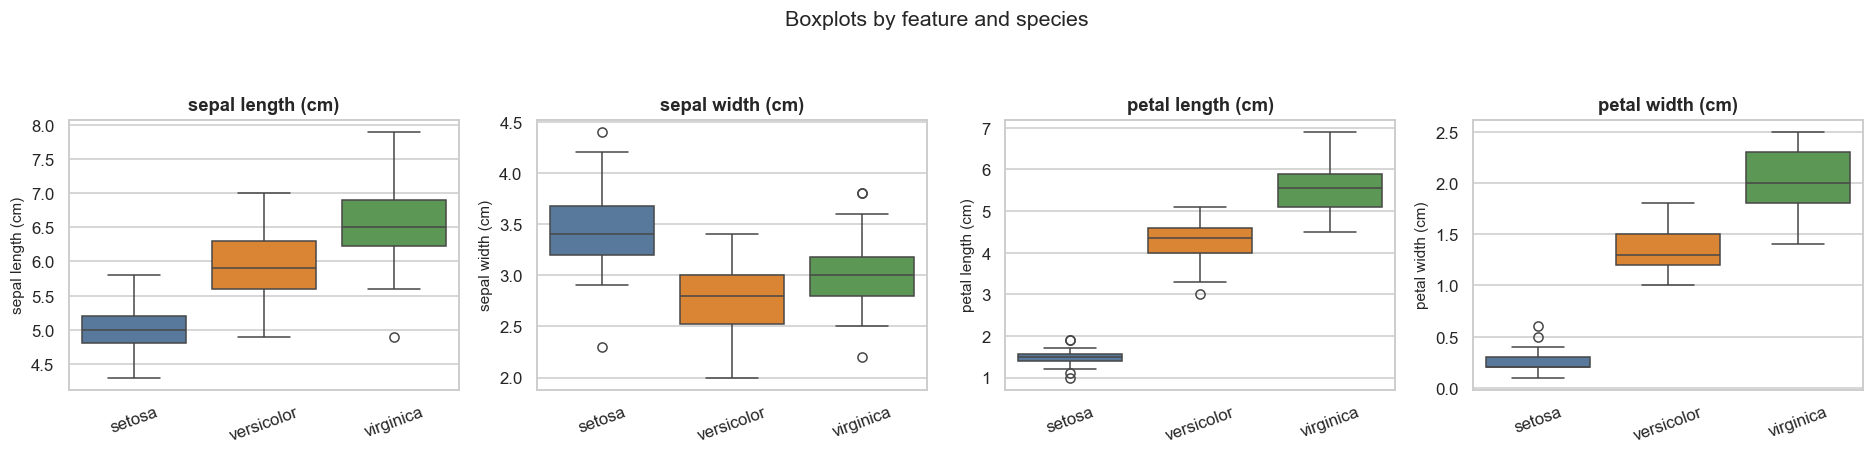

In [9]:
def plot_boxplots_by_species(
    features_df,
    target,
    class_names=CLASS_NAMES,
    palette=CLASS_PALETTE,
):
    plot_df = make_plot_df(features_df, target)
    n_features = len(features_df.columns)

    fig, axes = plt.subplots(
        1,
        n_features,
        figsize=(4.3 * n_features, 4.2)
    )

    axes = np.atleast_1d(axes)

    for axis, feature in zip(axes, features_df.columns):
        sns.boxplot(
            data=plot_df,
            x="species",
            y=feature,
            hue="species",
            order=class_names,
            hue_order=class_names,
            palette=palette,
            ax=axis,
            legend=False,
        )

        axis.set_title(feature)
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=20)

    fig.suptitle("Boxplots by feature and species", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


plot_boxplots_by_species(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

The boxplot summary reinforces the separation pattern observed in the previous scatter plots. For petal length, Setosa has a median of 1.50 cm and an interquartile interval from 1.40 cm to 1.58 cm, while Versicolor has a median of 4.35 cm and Virginica has a median of 5.55 cm. The distance between these medians explains why petal length provides strong visual separation among the three species.

Petal width shows a similar pattern. Setosa has a median of 0.20 cm, with most observations concentrated between 0.20 cm and 0.30 cm. Versicolor has a median of 1.30 cm, while Virginica has a median of 2.00 cm. The quartile intervals show a clear separation between Setosa and the other two species, supporting the expectation that a Decision Tree can isolate Setosa using a simple petal-based rule.

The separation between Versicolor and Virginica is weaker than the separation involving Setosa. For petal length, Versicolor ranges from 3.00 cm to 5.10 cm, while Virginica ranges from 4.50 cm to 6.90 cm, creating an overlap between 4.50 cm and 5.10 cm. For petal width, Versicolor ranges from 1.00 cm to 1.80 cm, while Virginica ranges from 1.40 cm to 2.50 cm, creating another overlap region between 1.40 cm and 1.80 cm. These overlap intervals help explain why later model errors are expected to occur mainly between these two classes.

The sepal variables show weaker discriminatory power. Sepal length ranges overlap substantially across species: Setosa ranges from 4.30 cm to 5.80 cm, Versicolor from 4.90 cm to 7.00 cm, and Virginica from 4.90 cm to 7.90 cm. Sepal width is even less clearly separated, with overlapping ranges across all three species. Therefore, sepal measurements may still contribute to some decision rules, but they are unlikely to be as decisive as petal length and petal width.

The potential outlier counts should not be interpreted immediately as data quality problems. For example, Setosa has four potential outliers in petal length and two in petal width, but these arise partly because its interquartile ranges are very narrow. In this context, these points are better interpreted as natural biological variation unless there is external evidence of measurement error.

#### Histograms by Variable and Species

Histograms are used to inspect the shape of each feature distribution by species. Before plotting the histograms, summary statistics are calculated to compare the center, dispersion, skewness, and value ranges of each feature within each class.

In [10]:
def summarize_distribution_by_species(features_df, target, species_map=SPECIES_MAP):
    """Create distribution-oriented summary statistics by species and feature."""
    plot_df = make_plot_df(features_df, target, species_map)

    summary_rows = []

    for species in CLASS_NAMES:
        species_df = plot_df[plot_df["species"] == species]

        for feature in features_df.columns:
            values = species_df[feature]

            summary_rows.append({
                "species": species,
                "feature": feature,
                "mean": values.mean(),
                "std": values.std(),
                "skew": values.skew(),
                "min": values.min(),
                "max": values.max(),
                "range": values.max() - values.min()
            })

    return pd.DataFrame(summary_rows)


distribution_summary_df = summarize_distribution_by_species(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

display(distribution_summary_df.round(2))

,species,feature,mean,std,skew,min,max,range
0,setosa,sepal length (cm),5.01,0.35,0.12,4.3,5.8,1.5
1,setosa,sepal width (cm),3.43,0.38,0.04,2.3,4.4,2.1
2,setosa,petal length (cm),1.46,0.17,0.11,1.0,1.9,0.9
3,setosa,petal width (cm),0.25,0.11,1.25,0.1,0.6,0.5
4,versicolor,sepal length (cm),5.94,0.52,0.11,4.9,7.0,2.1
5,versicolor,sepal width (cm),2.77,0.31,-0.36,2.0,3.4,1.4
6,versicolor,petal length (cm),4.26,0.47,-0.61,3.0,5.1,2.1
7,versicolor,petal width (cm),1.33,0.20,-0.03,1.0,1.8,0.8
8,virginica,sepal length (cm),6.59,0.64,0.12,4.9,7.9,3.0
9,virginica,sepal width (cm),2.97,0.32,0.37,2.2,3.8,1.6


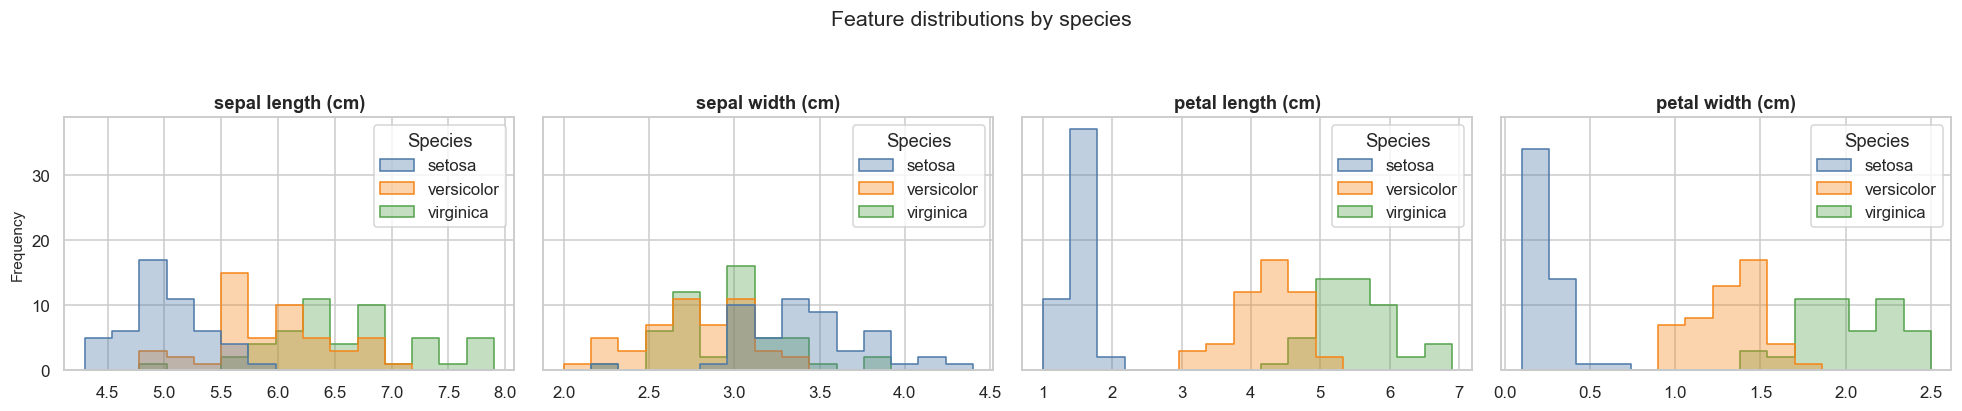

In [11]:
def plot_histograms_by_variable(
    features_df,
    target,
    class_names=CLASS_NAMES,
    palette=CLASS_PALETTE,
):
    plot_df = make_plot_df(features_df, target)
    n_features = len(features_df.columns)

    fig, axes = plt.subplots(
        1,
        n_features,
        figsize=(4.5 * n_features, 3.8),
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for axis, feature in zip(axes, features_df.columns):
        sns.histplot(
            data=plot_df,
            x=feature,
            hue="species",
            hue_order=class_names,
            palette=palette,
            bins=15,
            element="step",
            fill=True,
            alpha=0.35,
            common_bins=True,
            stat="count",
            ax=axis
        )

        axis.set_title(feature)
        axis.set_xlabel("")

        if axis.get_legend() is not None:
            axis.get_legend().set_title("Species")

    axes[0].set_ylabel("Frequency")
    fig.suptitle("Feature distributions by species", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


plot_histograms_by_variable(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

The distribution summary and histograms show that petal-related variables provide clearer class separation than sepal-related variables. For petal length, Setosa has a mean of 1.46 cm and ranges from 1.00 cm to 1.90 cm, while Versicolor has a mean of 4.26 cm and ranges from 3.00 cm to 5.10 cm. Since there is no overlap between the Setosa and Versicolor petal length ranges, this variable provides strong evidence for separating Setosa from the other classes.

Petal width follows the same pattern. Setosa has a mean of 0.25 cm and ranges from 0.10 cm to 0.60 cm, while Versicolor ranges from 1.00 cm to 1.80 cm and Virginica ranges from 1.40 cm to 2.50 cm. The gap between Setosa and Versicolor reinforces the expectation that Setosa can be isolated by a simple petal-based decision rule.

The distinction between Versicolor and Virginica is less clear. For petal width, the two classes overlap between 1.40 cm and 1.80 cm. For petal length, they overlap between 4.50 cm and 5.10 cm. These overlap regions suggest that future model errors are more likely to occur between Versicolor and Virginica than between Setosa and the other species.

The sepal measurements are less discriminative. Sepal length means increase from 5.01 cm for Setosa to 5.94 cm for Versicolor and 6.59 cm for Virginica, but the ranges overlap substantially. Sepal width shows even weaker separation, with means of 3.43 cm for Setosa, 2.77 cm for Versicolor, and 2.97 cm for Virginica, and overlapping ranges across all three species.

The skewness values are generally moderate, with the largest value appearing for Setosa petal width. However, the main classification signal does not come from distribution asymmetry. It comes from differences in location and overlap between species. Overall, the printed statistics and histograms support the expectation that the Decision Tree will rely primarily on petal length and petal width.

### Bivariate Analysis

#### Pairplot by Species

The pairplot is used to inspect relationships between pairs of numerical features while preserving the species labels. Before plotting, pairwise correlations and species-level feature means are calculated to support the visual interpretation with numerical evidence.

In [12]:
def summarize_pairwise_correlations(df, feature_columns=FEATURE_COLUMNS):
    """Create a sorted table with pairwise Pearson correlations between features."""
    correlation_matrix = df[feature_columns].corr(method="pearson")

    upper_triangle_mask = np.triu(
        np.ones(correlation_matrix.shape, dtype=bool),
        k=1
    )

    correlation_pairs_df = (
        correlation_matrix
        .where(upper_triangle_mask)
        .stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "pearson_correlation"
        })
        .dropna(subset=["pearson_correlation"])
    )

    correlation_pairs_df["absolute_correlation"] = (
        correlation_pairs_df["pearson_correlation"].abs()
    )

    correlation_pairs_df = (
        correlation_pairs_df
        .sort_values("absolute_correlation", ascending=False)
        .reset_index(drop=True)
    )

    return correlation_pairs_df


def summarize_species_feature_means(
    features_df,
    target,
    species_map=SPECIES_MAP
):
    """Create a table with mean feature values by species."""
    plot_df = features_df.copy()
    plot_df["species"] = pd.Series(target, index=features_df.index).map(species_map)

    species_means_df = (
        plot_df
        .groupby("species")[features_df.columns]
        .mean()
        .round(2)
    )

    return species_means_df


pairwise_correlations_df = summarize_pairwise_correlations(
    iris_df,
    FEATURE_COLUMNS
)

species_means_df = summarize_species_feature_means(
    iris_df[FEATURE_COLUMNS],
    iris_df["target"]
)

display(pairwise_correlations_df.round(3))
display(species_means_df)

,feature_1,feature_2,pearson_correlation,absolute_correlation
0,petal length (cm),petal width (cm),0.963,0.963
1,sepal length (cm),petal length (cm),0.872,0.872
2,sepal length (cm),petal width (cm),0.818,0.818
3,sepal width (cm),petal length (cm),-0.428,0.428
4,sepal width (cm),petal width (cm),-0.366,0.366
5,sepal length (cm),sepal width (cm),-0.118,0.118


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


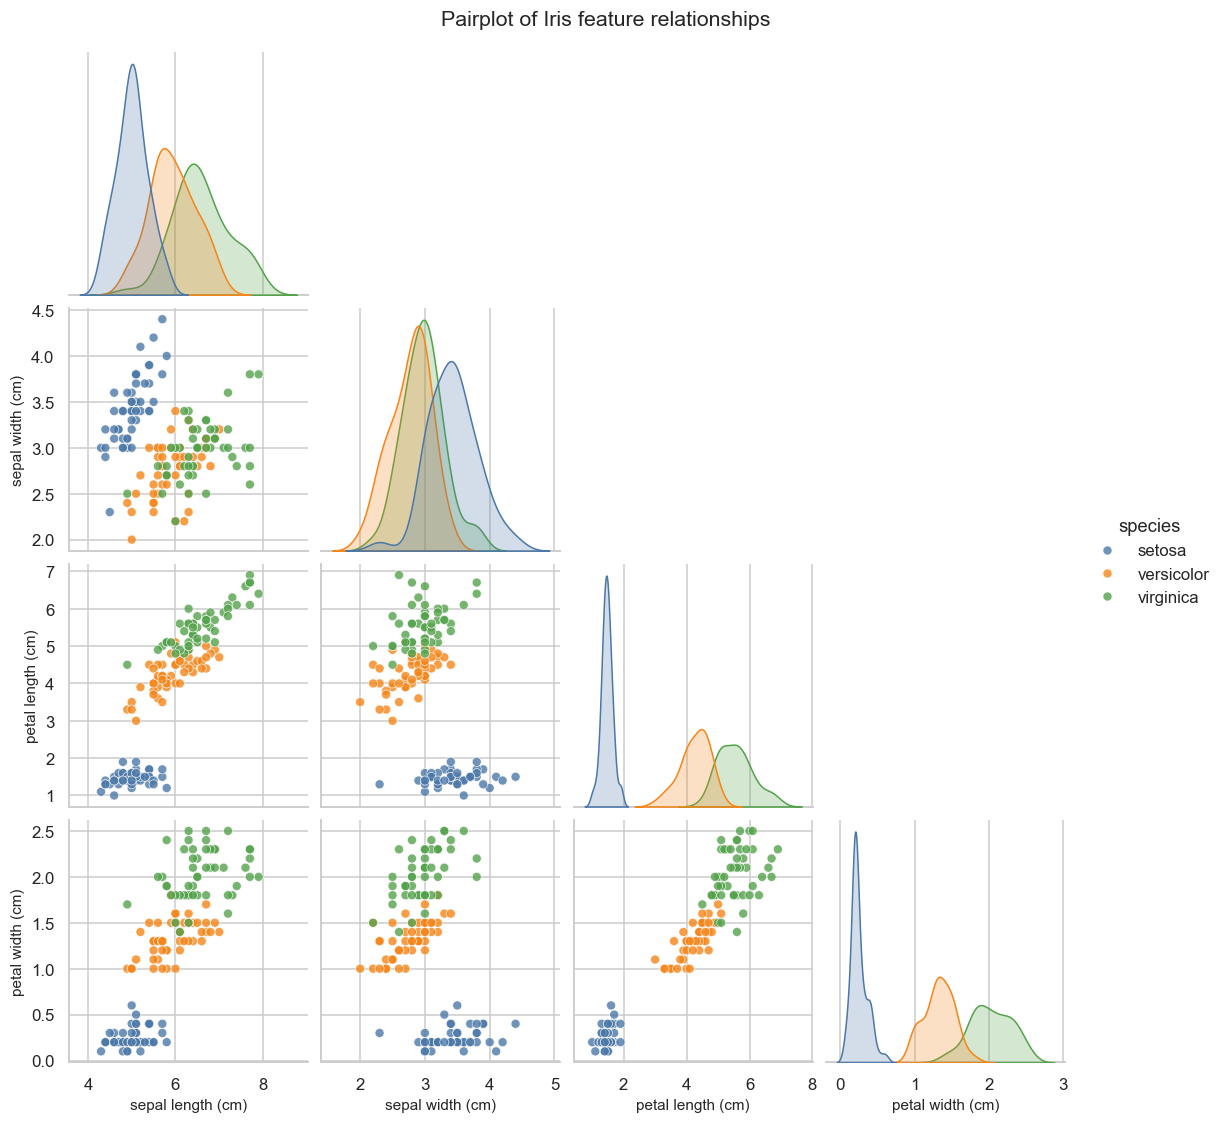

In [13]:
def plot_iris_pairplot(
    df,
    target_col="target",
    feature_columns=FEATURE_COLUMNS,
    species_map=SPECIES_MAP,
    palette=CLASS_PALETTE,
    title="Pairplot of Iris feature relationships",
):
    plot_df = df[feature_columns + [target_col]].copy()
    plot_df["species"] = plot_df[target_col].map(species_map)

    pair_grid = sns.pairplot(
        data=plot_df,
        vars=feature_columns,
        hue="species",
        palette=palette,
        diag_kind="kde",
        corner=True,
        plot_kws={"alpha": 0.8, "s": 35},
    )

    pair_grid.fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()

    return pair_grid


pair_grid = plot_iris_pairplot(df=iris_df)

The pairwise correlation table shows that the strongest relationship occurs between petal length and petal width, with a Pearson correlation of 0.963. This confirms the visual pattern observed in the pairplot, where these two variables form a clear positive relationship.

Sepal length also has strong positive correlations with petal length and petal width, with coefficients of 0.872 and 0.818, respectively. This indicates that larger flowers tend to have longer sepals and larger petal measurements. However, these relationships are still less direct than the relationship between the two petal variables.

Sepal width shows weaker relationships with the other measurements. Its correlation with petal length is -0.428 and its correlation with petal width is -0.366. The weakest relationship is between sepal length and sepal width, with a correlation of -0.118. This supports the visual impression that sepal width contributes less clearly to class separation.

The species-level mean table helps explain the separation observed in the pairplot. Setosa has much smaller petal measurements, with a mean petal length of 1.46 cm and a mean petal width of 0.25 cm. Versicolor has intermediate values, with means of 4.26 cm and 1.33 cm, while Virginica has the highest petal averages, with means of 5.55 cm and 2.03 cm.

These numerical results reinforce the previous univariate analysis. Petal length and petal width jointly provide the clearest separation, especially for Setosa. However, Versicolor and Virginica are closer to each other in the petal-based feature space, which suggests that the Decision Tree may require more specific rules to distinguish these two classes.

The correlation values should be interpreted as exploratory evidence rather than causal relationships. They describe how the measurements vary together in this dataset, but they do not imply that one flower measurement causes another.

### Dimensionality Reduction with t-SNE

t-SNE is applied as an exploratory dimensionality reduction technique to project the four standardized Iris features into a two-dimensional space. The goal is not to validate the classifier, but to inspect whether the observations form visually distinguishable groups in a lower-dimensional representation.

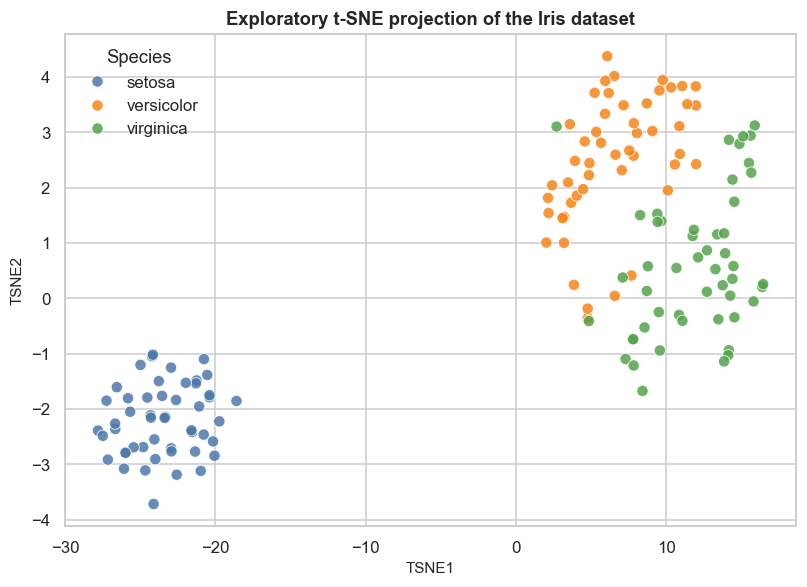

In [14]:
def plot_tsne_iris(
    df,
    target_col="target",
    feature_columns=FEATURE_COLUMNS,
    species_map=SPECIES_MAP,
    palette=CLASS_PALETTE,
    perplexity=30,
    random_state=RANDOM_STATE,
    figsize=(7.5, 5.5),
    title="Exploratory t-SNE projection of the Iris dataset",
):
    if perplexity >= len(df):
        raise ValueError("t-SNE perplexity must be smaller than the number of samples.")

    tsne_df = df.copy()
    missing_columns = [col for col in feature_columns if col not in tsne_df.columns]
    if missing_columns:
        raise ValueError(f"Missing feature columns: {missing_columns}")

    tsne_df["species"] = tsne_df[target_col].map(species_map)
    scaled_features = StandardScaler().fit_transform(tsne_df[feature_columns])

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    tsne_features = tsne.fit_transform(scaled_features)

    tsne_df["TSNE1"] = tsne_features[:, 0]
    tsne_df["TSNE2"] = tsne_features[:, 1]

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=tsne_df,
        x="TSNE1",
        y="TSNE2",
        hue="species",
        palette=palette,
        alpha=0.85,
        s=55,
        ax=ax,
    )

    ax.set_title(title)
    ax.legend(title="Species", frameon=False)
    plt.tight_layout()
    plt.show()

    return tsne_df


tsne_df = plot_tsne_iris(df=iris_df)

The t-SNE projection shows a clear separation between Setosa and the other two species in the reduced two-dimensional space. Setosa observations form a compact cluster on the left side of the plot, which is consistent with the previous exploratory analyses showing that this species has much smaller petal length and petal width values.

Versicolor and Virginica appear closer to each other in the projected space, with partial proximity between their clusters. This reinforces the pattern already observed in the pairplot, histograms, and boxplots: the main separation challenge is not between Setosa and the other species, but between Versicolor and Virginica.

This visualization supports the expectation that a Decision Tree model should classify Setosa with relatively simple rules, while requiring more specific decision boundaries to distinguish Versicolor from Virginica. However, t-SNE is used here only as an exploratory visualization technique. It does not validate the classifier and should not be interpreted as direct evidence of predictive performance.

## 4. Modeling, Validation, and Visualization

The modeling section converts the exploratory findings into a supervised classification workflow.

### Feature and Target Definition

The feature matrix contains only the four numerical flower measurements. The target vector contains the encoded species label. Explicitly separating these objects keeps the original DataFrame unchanged and makes the modeling inputs clear.

In [15]:
features = iris_df[FEATURE_COLUMNS].copy()
target = iris_df["target"].copy()

print(f"Feature matrix shape: {features.shape}")
print(f"Target vector shape: {target.shape}")

Feature matrix shape: (150, 4)
Target vector shape: (150,)


The model uses all four original Iris measurements. No feature engineering is required for this benchmark dataset, which keeps the analysis focused on how a Decision Tree partitions the original measurement space.

### Train/Test Split

A stratified holdout split preserves the class proportions in both training and test sets. This matters because each Iris species is equally represented, and the evaluation should not be distorted by an accidental class imbalance in the test partition.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)


def summarize_class_distribution(labels, name):
    return (
        labels
        .map(SPECIES_MAP)
        .value_counts()
        .reindex(CLASS_NAMES)
        .rename_axis("species")
        .rename(name)
    )


split_distribution_df = pd.concat(
    [
        summarize_class_distribution(target, "full_dataset"),
        summarize_class_distribution(y_train, "train_set"),
        summarize_class_distribution(y_test, "test_set"),
    ],
    axis=1,
)

display(split_distribution_df)

,full_dataset,train_set,test_set
species,,,
setosa,50,40,10
versicolor,50,40,10
virginica,50,40,10


The class distribution table confirms that the original dataset contains 50 observations for each species. After the stratified split, the training set contains 40 observations per species and the test set contains 10 observations per species.

This confirms that the 80/20 split preserved the class balance across Setosa, Versicolor, and Virginica. As a result, the holdout evaluation will include all three classes equally and will not be distorted by an accidental imbalance in the test partition.

The test set remains untouched during training and will be used only after the Decision Tree has been fitted on the training data.

### Decision Tree Model Training

The Decision Tree is trained with the entropy criterion so the later entropy diagnostics align with the model's split objective. The tree remains intentionally simple and interpretable compared with more complex ensemble models.

In [17]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Tree depth: 5
Number of leaves: 8


The trained Decision Tree has a depth of 5 and 8 terminal leaves. This indicates that the model is still relatively interpretable, but it is not limited to only one or two broad decision rules.

A depth of 5 means that some observations require several sequential splits before reaching a final prediction. This is consistent with the exploratory analysis, where Setosa appeared easy to separate, while Versicolor and Virginica showed overlapping regions.

The 8 leaf nodes represent the final prediction regions learned by the model. Since the tree was trained with the entropy criterion, the following diagnostic sections can inspect how class impurity is reduced across these nodes and whether deeper branches are associated with the more difficult class boundary between Versicolor and Virginica.

### Holdout Evaluation

The holdout set estimates how the fitted tree performs on observations not used during training. The classification report is useful because aggregate accuracy can hide class-specific errors.

In [18]:
def evaluate_classifier(fitted_model, X_eval, y_eval, class_names):
    predictions = fitted_model.predict(X_eval)
    accuracy = accuracy_score(y_eval, predictions)

    report_df = pd.DataFrame(
        classification_report(
            y_eval,
            predictions,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    print(f"Accuracy: {accuracy:.4f}")
    display(report_df.round(3))

    return predictions, accuracy, report_df


y_pred, accuracy, classification_report_df = evaluate_classifier(
    model,
    X_test,
    y_test,
    CLASS_NAMES,
)

Accuracy: 0.9333


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,10.000
versicolor,0.900,0.900,0.900,10.000
virginica,0.900,0.900,0.900,10.000
accuracy,0.933,0.933,0.933,0.933
macro avg,0.933,0.933,0.933,30.000
weighted avg,0.933,0.933,0.933,30.000


The Decision Tree achieved a holdout accuracy of `0.9333`, meaning that it correctly classified 28 out of the 30 test observations. This indicates strong predictive performance on the held-out test set, although the result should still be interpreted cautiously because the Iris dataset is small.

The classification report shows perfect performance for Setosa, with precision, recall, and F1-score equal to `1.00`. This result is consistent with the exploratory analysis, where Setosa appeared clearly separated from the other species, especially through petal length and petal width.

Versicolor and Virginica show lower class-specific performance, with precision, recall, and F1-score around `0.90`. This suggests that the model errors are concentrated between these two classes, which matches the overlap observed earlier in the boxplots, histograms, pairplot, and t-SNE projection.

Therefore, the holdout evaluation confirms the main expectation from the EDA: Setosa is easy to classify, while the more difficult decision boundary lies between Versicolor and Virginica.

### Cross-Validation

Cross-validation gives a more stable view of performance than a single holdout split. It repeatedly evaluates cloned versions of the same Decision Tree on stratified folds, reducing the chance that the evaluation is driven by one favorable or unfavorable split.

In [19]:
cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_scores = cross_val_score(
    model,
    features,
    target,
    cv=cv,
    scoring="accuracy",
)

cv_results_df = pd.DataFrame({
    "fold": np.arange(1, CV_SPLITS + 1),
    "accuracy": cv_scores,
})

cv_summary_df = pd.DataFrame({
    "mean_accuracy": [cv_scores.mean()],
    "std_accuracy": [cv_scores.std(ddof=1)],
    "min_accuracy": [cv_scores.min()],
    "max_accuracy": [cv_scores.max()],
})

display(cv_results_df.round(4))
display(cv_summary_df.round(4))

,fold,accuracy
0,1,1.0000
1,2,0.9667
2,3,0.9333
3,4,0.9667
4,5,0.9000


,mean_accuracy,std_accuracy,min_accuracy,max_accuracy
0,0.9533,0.038,0.9,1.0


The cross-validation results show that the Decision Tree maintained strong performance across the five stratified folds. Fold accuracies ranged from `0.9000` to `1.0000`, indicating that the model performed well across different train/test partitions, but with some variation depending on the specific fold.

The mean cross-validation accuracy was `0.9533`, which is slightly higher than the holdout accuracy of `0.9333`. This suggests that the holdout result is consistent with the broader validation pattern and does not appear to be an isolated favorable result.

The standard deviation of `0.0380` indicates moderate variability across folds. This variability is expected because the Iris dataset is small, and each fold contains a limited number of observations. A small change in the number of misclassified samples can noticeably affect the fold accuracy.

Overall, cross-validation provides a more robust estimate of model performance than the single holdout split. The holdout set remains useful for concrete diagnostic analyses, such as the confusion matrix, decision paths, and inspection of misclassified observations.

### Confusion Matrix

The confusion matrix shows exactly which classes are confused on the holdout set. This complements precision, recall, and F1-score by making the error pattern visible.

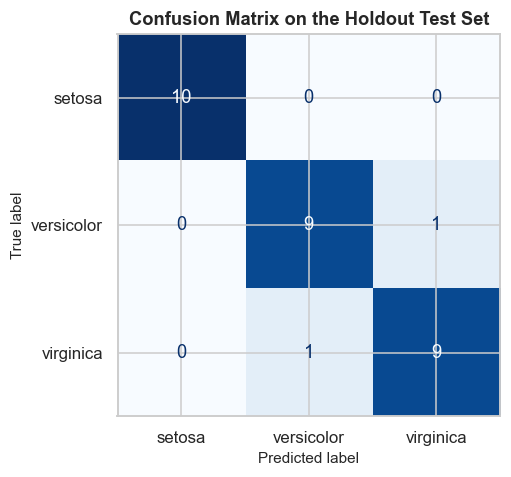

In [20]:
def plot_confusion_matrix(y_true, y_predicted, class_names):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_predicted,
        display_labels=class_names,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title("Confusion Matrix on the Holdout Test Set")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred, CLASS_NAMES)

The confusion matrix shows that all 10 Setosa observations in the holdout test set were correctly classified as Setosa. There were no cases where Setosa was confused with Versicolor or Virginica, which is consistent with the exploratory analysis showing that Setosa occupies a clearly distinct petal-size region.

For Versicolor, 9 out of 10 observations were correctly classified, while 1 observation was incorrectly predicted as Virginica. For Virginica, 9 out of 10 observations were correctly classified, while 1 observation was incorrectly predicted as Versicolor.

Therefore, the model made 2 errors out of 30 test observations, matching the holdout accuracy of `0.9333`. Both errors occurred between Versicolor and Virginica, and no error involved Setosa. This confirms the pattern observed throughout the EDA: the main classification boundary is not between Setosa and the other species, but between Versicolor and Virginica.

The confusion matrix also explains why the classification report showed perfect metrics for Setosa and lower, but still strong, metrics for Versicolor and Virginica. The model performs well overall, but its remaining uncertainty is concentrated in the region where the two non-Setosa species overlap.

### Feature Importance

Decision Tree impurity-based feature importance summarizes how much each feature contributes to reducing impurity across the fitted tree. Permutation importance is added as a complementary check: it measures how much test accuracy changes when one feature is randomly shuffled.

,feature,impurity_importance
0,petal length (cm),0.6649
1,petal width (cm),0.3036
2,sepal width (cm),0.0250
3,sepal length (cm),0.0065


,feature,permutation_importance_mean,permutation_importance_std
0,petal length (cm),0.5067,0.0841
1,petal width (cm),0.1089,0.0523
2,sepal width (cm),0.0111,0.0157
3,sepal length (cm),-0.0133,0.0163


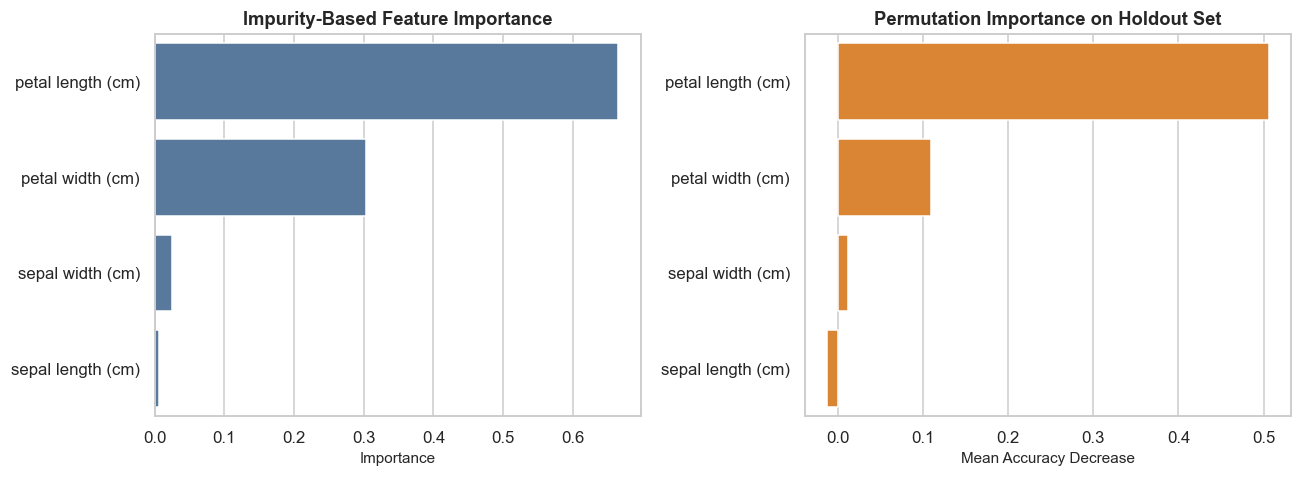

In [21]:
feature_importance_df = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "impurity_importance": model.feature_importances_,
    })
    .sort_values("impurity_importance", ascending=False)
    .reset_index(drop=True)
)

permutation_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=N_PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    scoring="accuracy",
)

permutation_importance_df = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "permutation_importance_mean": permutation_result.importances_mean,
        "permutation_importance_std": permutation_result.importances_std,
    })
    .sort_values("permutation_importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.round(4))
display(permutation_importance_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(
    data=feature_importance_df,
    x="impurity_importance",
    y="feature",
    color=CLASS_PALETTE["setosa"],
    ax=axes[0],
)
axes[0].set_title("Impurity-Based Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

sns.barplot(
    data=permutation_importance_df,
    x="permutation_importance_mean",
    y="feature",
    color=CLASS_PALETTE["versicolor"],
    ax=axes[1],
)
axes[1].set_title("Permutation Importance on Holdout Set")
axes[1].set_xlabel("Mean Accuracy Decrease")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The feature importance results confirm the pattern observed throughout the exploratory analysis and the tree diagnostics. In the impurity-based importance table, petal length is the dominant predictor, with an importance of `0.6649`, followed by petal width with `0.3036`. Sepal width and sepal length contribute much less to impurity reduction, with importance values of `0.0250` and `0.0065`, respectively.

The permutation importance results lead to a similar interpretation. When petal length is shuffled in the holdout set, the model accuracy decreases by an average of `0.5067`, which indicates that the model relies heavily on this feature for prediction. Petal width also contributes to predictive performance, but with a smaller mean accuracy decrease of `0.1089`. Sepal width has a very small positive permutation importance of `0.0111`, while sepal length has a slightly negative value of `-0.0133`.

The negative permutation importance for sepal length should not be interpreted as evidence that the feature is harmful in a general sense. Since the holdout set contains only 30 observations, small changes in prediction results can produce unstable permutation estimates. In this case, the value suggests that sepal length adds little useful information to the fitted tree on this specific test split.

Both importance methods therefore support the same main conclusion: petal length is the most influential feature in the Decision Tree, followed by petal width. This is consistent with the pairplot, histograms, boxplots, and the first split of the tree, where petal measurements provided the clearest class separation.

However, these values should be interpreted as model-specific evidence rather than causal or universal feature importance. Impurity-based importance can distribute credit unevenly when predictors are correlated, and the earlier correlation analysis showed that petal length and petal width are strongly correlated. Permutation importance provides a complementary view, but it is also sensitive to correlated predictors and to the small size of the holdout set.

### Tree Visualization

The tree visualization exposes the actual decision rules learned by the classifier. This is one of the main advantages of using a Decision Tree for this portfolio project: the fitted model can be inspected directly rather than treated as a black box.

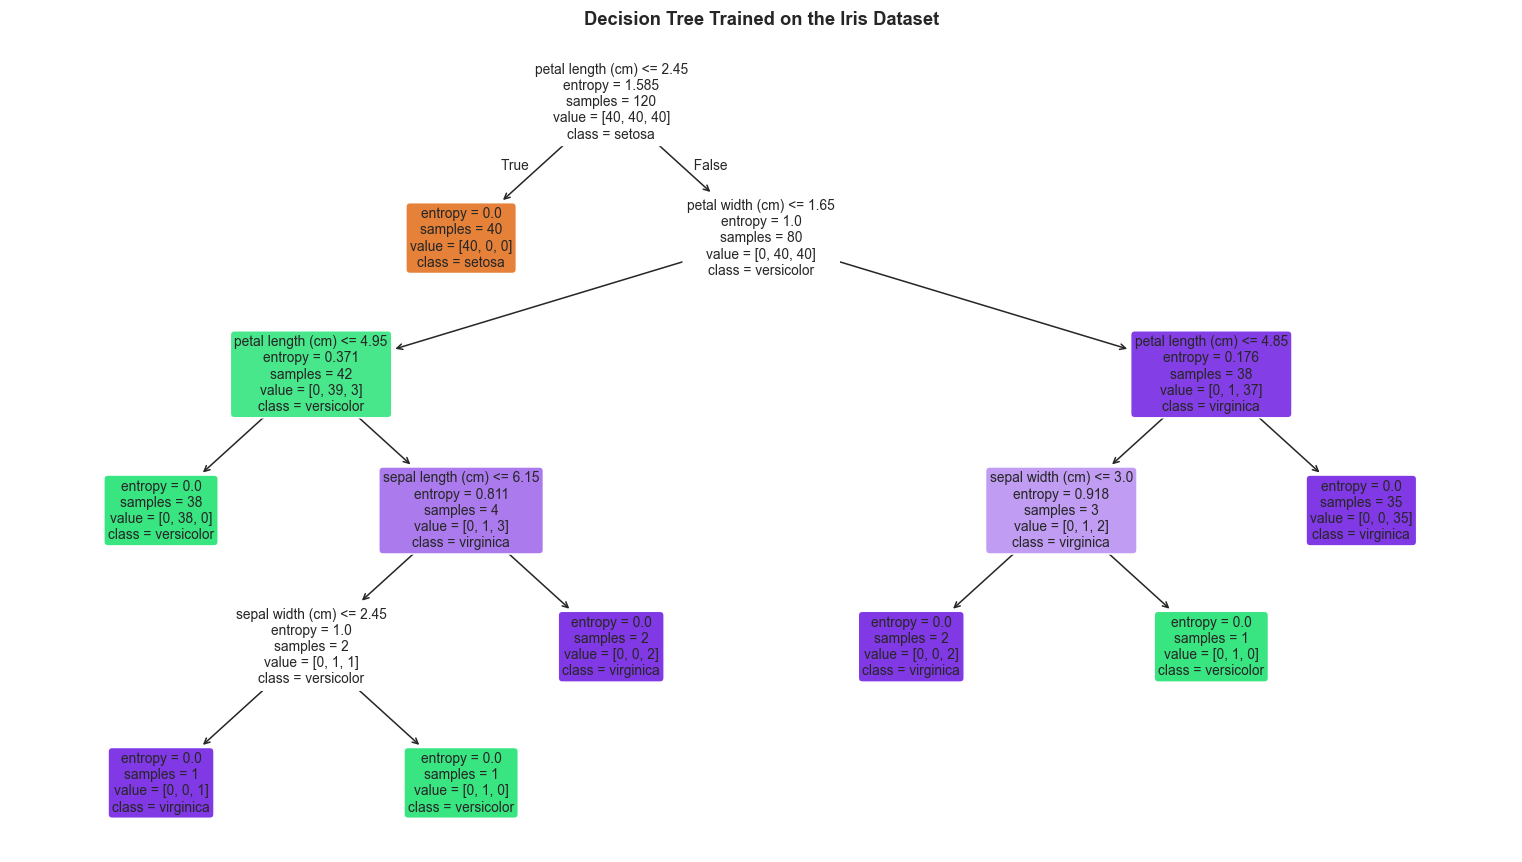

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(
    model,
    feature_names=FEATURE_COLUMNS,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree Trained on the Iris Dataset")
plt.tight_layout()
plt.show()

The tree visualization confirms that the first split is based on petal length, with the rule `petal length (cm) <= 2.45`. This split immediately separates all 40 Setosa observations in the training set into a pure leaf node, with entropy equal to `0.0` and class distribution `[40, 0, 0]`. This result is consistent with the EDA, where Setosa appeared clearly separated by petal-related measurements.

After Setosa is separated, the remaining branch contains 80 observations, evenly divided between Versicolor and Virginica, with class distribution `[0, 40, 40]` and entropy equal to `1.0`. The next split uses `petal width (cm) <= 1.65`, confirming that the model relies mainly on petal measurements to separate the two non-Setosa species.

The deeper branches occur mainly in the regions where Versicolor and Virginica overlap. For example, some nodes contain very small sample sizes, such as 4, 3, 2, or even 1 observation. These local rules help the tree correctly classify borderline cases, but they should be interpreted with caution because they may be more sensitive to the specific training split.

Overall, the visualization confirms the main pattern observed throughout the notebook: Setosa is separated by a simple and pure rule, while Versicolor and Virginica require more specific decision boundaries. This supports the later use of decision path analysis, entropy diagnostics, and pruning checks to evaluate whether the deeper branches represent useful structure or possible overfitting.

### Model Complexity and Pruning

Decision Trees can overfit by growing branches that capture small local patterns in the training data. Cost-complexity pruning evaluates simpler trees controlled by `ccp_alpha`. The goal here is not to force pruning to improve performance, but to check whether a simpler tree performs comparably under cross-validation.

,ccp_alpha,mean_cv_accuracy,std_cv_accuracy,tree_depth,n_leaves
0,0.00000,0.94167,0.02282,5,8
1,0.01352,0.94167,0.02282,4,6
2,0.02296,0.94167,0.02282,3,5
3,0.03264,0.95000,0.03486,3,4
4,0.10289,0.93333,0.02282,2,3
5,0.48114,0.89167,0.12707,1,2


,model,ccp_alpha,holdout_accuracy,train_cv_mean_accuracy,tree_depth,n_leaves
0,Original tree,0.00000,0.93333,0.94167,5,8
1,Pruned tree (CV-selected alpha),0.03264,0.96667,0.95000,3,4


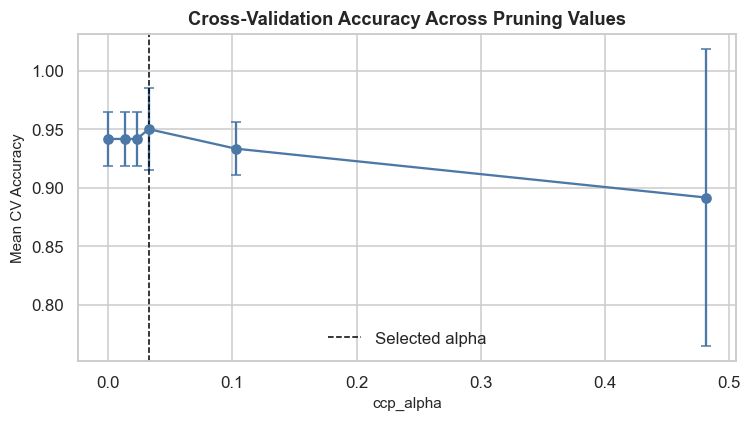

In [23]:
pruning_path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alpha_candidates = np.unique(pruning_path.ccp_alphas)

# The largest alpha usually collapses the tree to a root-only model, so it is excluded.
if len(ccp_alpha_candidates) > 1:
    ccp_alpha_candidates = ccp_alpha_candidates[:-1]

pruning_cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

pruning_rows = []

for alpha in ccp_alpha_candidates:
    candidate_model = DecisionTreeClassifier(
        criterion="entropy",
        random_state=RANDOM_STATE,
        ccp_alpha=alpha,
    )
    candidate_scores = cross_val_score(
        candidate_model,
        X_train,
        y_train,
        cv=pruning_cv,
        scoring="accuracy",
    )

    candidate_model.fit(X_train, y_train)

    pruning_rows.append({
        "ccp_alpha": alpha,
        "mean_cv_accuracy": candidate_scores.mean(),
        "std_cv_accuracy": candidate_scores.std(ddof=1),
        "tree_depth": candidate_model.get_depth(),
        "n_leaves": candidate_model.get_n_leaves(),
    })

pruning_results_df = pd.DataFrame(pruning_rows).sort_values("ccp_alpha").reset_index(drop=True)

display(pruning_results_df.round(5))

best_pruning_index = pruning_results_df.sort_values(
    ["mean_cv_accuracy", "n_leaves"],
    ascending=[False, True],
).index[0]

best_alpha = pruning_results_df.loc[best_pruning_index, "ccp_alpha"]

pruned_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=RANDOM_STATE,
    ccp_alpha=best_alpha,
)
pruned_model.fit(X_train, y_train)
pruned_y_pred = pruned_model.predict(X_test)
pruned_accuracy = accuracy_score(y_test, pruned_y_pred)

original_train_cv_scores = cross_val_score(
    DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv=pruning_cv,
    scoring="accuracy",
)

complexity_comparison_df = pd.DataFrame([
    {
        "model": "Original tree",
        "ccp_alpha": 0.0,
        "holdout_accuracy": accuracy,
        "train_cv_mean_accuracy": original_train_cv_scores.mean(),
        "tree_depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
    },
    {
        "model": "Pruned tree (CV-selected alpha)",
        "ccp_alpha": best_alpha,
        "holdout_accuracy": pruned_accuracy,
        "train_cv_mean_accuracy": pruning_results_df.loc[best_pruning_index, "mean_cv_accuracy"],
        "tree_depth": pruned_model.get_depth(),
        "n_leaves": pruned_model.get_n_leaves(),
    },
])

display(complexity_comparison_df.round(5))

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    pruning_results_df["ccp_alpha"],
    pruning_results_df["mean_cv_accuracy"],
    yerr=pruning_results_df["std_cv_accuracy"],
    marker="o",
    linewidth=1.5,
    capsize=3,
    color=CLASS_PALETTE["setosa"],
)
ax.axvline(best_alpha, color="black", linestyle="--", linewidth=1, label="Selected alpha")
ax.set_title("Cross-Validation Accuracy Across Pruning Values")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Mean CV Accuracy")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The pruning results show that the original Decision Tree, with `ccp_alpha = 0.00000`, has a mean cross-validation accuracy of `0.94167`, depth `5`, and `8` leaves when evaluated on the training set folds. This indicates strong performance, but also shows that the unpruned tree creates a relatively more complex structure.

The best cross-validation result among the tested pruning values occurs at `ccp_alpha = 0.03264`, with a mean cross-validation accuracy of `0.95000`. This pruned tree is simpler than the original model, reducing the depth from `5` to `3` and the number of leaves from `8` to `4`.

The complexity comparison table shows that the pruned tree also achieved higher holdout accuracy, increasing from `0.93333` for the original tree to `0.96667` for the pruned tree. In practical terms, this means that the pruned model correctly classified one additional observation in the 30-sample holdout test set.

This result suggests that the original tree may contain some overly specific branches that are not necessary for good predictive performance. The pruned tree preserves strong accuracy while using fewer decision rules, which makes it easier to interpret.

However, this improvement should be interpreted cautiously. The Iris dataset is small, and the holdout test set contains only 30 observations, so a difference of one prediction changes the accuracy noticeably. The pruning analysis should therefore be understood primarily as evidence that a simpler tree can perform comparably or slightly better, rather than as definitive proof that the selected pruned tree is universally superior.

Overall, cost-complexity pruning improves the professional robustness of the workflow by checking whether model simplicity can be achieved without sacrificing predictive performance. In this case, the selected pruned tree appears preferable because it is shallower, has fewer leaves, and maintains strong validation and holdout performance.

## 5. Model Diagnostics and Interpretability

The previous section evaluated predictive performance. This section inspects how the fitted Decision Tree makes decisions. The diagnostics focus on node structure, path length, individual examples, and misclassified observations.

### Internal Tree Structure and Node Depths

Internal nodes represent decision rules, while leaf nodes represent terminal predictions. Node depth shows how many decisions are needed to reach a node. This helps distinguish broad, simple rules from deeper local rules.

In [24]:
def build_tree_node_summary(fitted_model, class_names):
    fitted_tree = fitted_model.tree_
    n_nodes = fitted_tree.node_count

    depths = np.zeros(n_nodes, dtype=int)
    is_leaf = np.zeros(n_nodes, dtype=bool)

    stack = [(0, 0)]
    while stack:
        node_id, depth = stack.pop()
        depths[node_id] = depth

        left_child = fitted_tree.children_left[node_id]
        right_child = fitted_tree.children_right[node_id]

        if left_child == right_child:
            is_leaf[node_id] = True
        else:
            stack.append((left_child, depth + 1))
            stack.append((right_child, depth + 1))

    raw_values = fitted_tree.value[:, 0, :]
    row_sums = raw_values.sum(axis=1)

    # scikit-learn versions may store either class counts or normalized proportions.
    if np.allclose(row_sums[row_sums > 0], 1.0):
        class_counts = raw_values * fitted_tree.weighted_n_node_samples.reshape(-1, 1)
    else:
        class_counts = raw_values

    majority_class_ids = np.argmax(class_counts, axis=1)

    summary_df = pd.DataFrame({
        "node_id": np.arange(n_nodes),
        "depth": depths,
        "n_samples": fitted_tree.n_node_samples,
        "entropy_bits": fitted_tree.impurity,
        "node_type": np.where(is_leaf, "leaf", "internal"),
        "majority_class": [class_names[class_id] for class_id in majority_class_ids],
    })

    for class_id, class_name in enumerate(class_names):
        summary_df[f"{class_name}_count"] = class_counts[:, class_id].round(0).astype(int)

    return summary_df


tree_node_summary_df = build_tree_node_summary(model, CLASS_NAMES)

display(tree_node_summary_df.round({"entropy_bits": 4}))

,node_id,depth,n_samples,entropy_bits,node_type,majority_class,setosa_count,versicolor_count,virginica_count
0,0,0,120,1.5850,internal,setosa,40,40,40
1,1,1,40,0.0000,leaf,setosa,40,0,0
2,2,1,80,1.0000,internal,versicolor,0,40,40
3,3,2,42,0.3712,internal,versicolor,0,39,3
4,4,3,38,0.0000,leaf,versicolor,0,38,0
5,5,3,4,0.8113,internal,virginica,0,1,3
6,6,4,2,1.0000,internal,versicolor,0,1,1
7,7,5,1,0.0000,leaf,virginica,0,0,1
8,8,5,1,0.0000,leaf,versicolor,0,1,0
9,9,4,2,0.0000,leaf,virginica,0,0,2


The node summary makes the internal structure of the fitted tree explicit. The original tree contains 15 nodes, including 8 terminal leaves and 7 internal decision nodes. The maximum depth is 5, which confirms that some observations require several sequential decision rules before reaching a final prediction.

Node 1 is a shallow leaf at depth 1, containing 40 Setosa observations, entropy equal to 0.0000, and class counts `[40, 0, 0]`. This confirms that Setosa is separated immediately after the root split by a broad and pure rule.

Node 2, at depth 1, contains 80 observations split between Versicolor and Virginica, with class counts `[0, 40, 40]` and entropy equal to 1.0000. This shows that, after Setosa is removed, the remaining uncertainty is concentrated entirely between the two non-Setosa species.

Several deeper nodes contain very few observations. For example, node 5 contains only 4 samples, node 6 contains 2 samples, and node 11 contains 3 samples. These nodes have relatively high entropy values, such as 0.8113, 1.0000, and 0.9183, indicating local uncertainty in small regions of the feature space.

This pattern supports the previous interpretation: the tree uses a simple and stable rule to classify Setosa, while deeper and more specific branches are needed to separate Versicolor from Virginica. The `majority_class` column should be interpreted as the dominant class within a node, or as a tie when class counts are equal. It should only be treated as a final model prediction when the node is a leaf.

### Correctly Classified Sample and Leaf Node

A correctly classified Setosa example provides a simple reference case. It shows how an easy observation reaches a terminal leaf with few decisions.

In [25]:
setosa_id = CLASS_NAMES.index("setosa")

correct_setosa_positions = np.flatnonzero(
    (y_test.to_numpy() == setosa_id) & (y_pred == setosa_id)
)

if correct_setosa_positions.size > 0:
    sample_position = int(correct_setosa_positions[0])
else:
    sample_position = 0

sample = X_test.iloc[[sample_position]]
sample_index = sample.index[0]

predicted_class_id = int(model.predict(sample)[0])
true_class_id = int(y_test.loc[sample_index])
leaf_node = int(model.apply(sample)[0])

decision_path = model.decision_path(sample).indices.tolist()

correct_sample_summary_df = pd.DataFrame({
    "test_position": [sample_position],
    "original_index": [sample_index],
    "true_class": [CLASS_NAMES[true_class_id]],
    "predicted_class": [CLASS_NAMES[predicted_class_id]],
    "reached_leaf_node": [leaf_node],
    "decision_path": [decision_path],
    "prediction_correct": [predicted_class_id == true_class_id],
})

display(correct_sample_summary_df)

display(
    sample
    .T
    .rename(columns={sample_index: "feature_value"})
)

,test_position,original_index,true_class,predicted_class,reached_leaf_node,decision_path,prediction_correct
0,0,38,setosa,setosa,1,"[0, 1]",True


,feature_value
sepal length (cm),4.4
sepal width (cm),3.0
petal length (cm),1.3
petal width (cm),0.2


The selected correctly classified example is test position `0`, corresponding to original dataset index `38`. Its true class is Setosa and the model also predicted Setosa, so the prediction is correct. The observation reached leaf node `1`, following the decision path `[0, 1]`.

The feature values explain why this observation follows a simple path. Its petal length is `1.30 cm` and its petal width is `0.20 cm`, which are both within the low petal-measurement region previously associated with Setosa. In the tree visualization, the root split separates observations with petal length less than or equal to `2.45 cm`, so this sample is classified as Setosa after only one decision rule.

This example illustrates the simplest model behavior: Setosa observations are separated early because their petal measurements occupy a distinct region of the feature space. It provides a useful reference case before inspecting misclassified or borderline observations, where the tree usually needs deeper and more specific decision paths.

### Decision Paths on the Test Set

A decision path is the sequence of nodes visited by a sample before it reaches a leaf. Comparing paths across test observations shows whether the tree uses short, broad rules or deeper, more specific rules for each class.

In [26]:
decision_paths = model.decision_path(X_test)
leaf_nodes = model.apply(X_test)

path_rows = []

for position, (sample_index, actual_class_id, predicted_class_id, leaf_node) in enumerate(
    zip(X_test.index, y_test.to_numpy(), y_pred, leaf_nodes)
):
    actual_class_id = int(actual_class_id)
    predicted_class_id = int(predicted_class_id)
    node_path = decision_paths[position].indices.tolist()

    path_rows.append({
        "test_position": position,
        "original_index": sample_index,
        "node_path": node_path,
        "path_length": len(node_path),
        "leaf_node": int(leaf_node),
        "predicted_class": CLASS_NAMES[predicted_class_id],
        "actual_class": CLASS_NAMES[actual_class_id],
        "correct_prediction": predicted_class_id == actual_class_id,
    })

results_df = pd.DataFrame(path_rows)

display(results_df)

,test_position,original_index,node_path,path_length,leaf_node,predicted_class,actual_class,correct_prediction
0,0,38,"[0, 1]",2,1,setosa,setosa,True
1,1,127,"[0, 2, 10, 14]",4,14,virginica,virginica,True
2,2,57,"[0, 2, 3, 4]",4,4,versicolor,versicolor,True
3,3,93,"[0, 2, 3, 4]",4,4,versicolor,versicolor,True
4,4,42,"[0, 1]",2,1,setosa,setosa,True
5,5,56,"[0, 2, 3, 4]",4,4,versicolor,versicolor,True
6,6,22,"[0, 1]",2,1,setosa,setosa,True
7,7,20,"[0, 1]",2,1,setosa,setosa,True
8,8,147,"[0, 2, 10, 14]",4,14,virginica,virginica,True
9,9,84,"[0, 2, 3, 4]",4,4,versicolor,versicolor,True


In [27]:
misclassified_df = results_df.loc[~results_df["correct_prediction"]].copy()

display(misclassified_df)

path_accuracy = results_df["correct_prediction"].mean()
print(f"Correct predictions: {results_df['correct_prediction'].sum()} out of {len(results_df)}")
print(f"Accuracy from decision path table: {path_accuracy:.4f}")

,test_position,original_index,node_path,path_length,leaf_node,predicted_class,actual_class,correct_prediction
23,23,134,"[0, 2, 3, 5, 6, 8]",6,8,versicolor,virginica,False
25,25,77,"[0, 2, 10, 14]",4,14,virginica,versicolor,False


Correct predictions: 28 out of 30
Accuracy from decision path table: 0.9333


The decision-path table links the aggregate holdout performance to the routing behavior of each individual test observation. The model correctly classified 28 out of 30 observations, producing an accuracy of `0.9333`, which matches the previous holdout evaluation.

All Setosa observations follow the short path `[0, 1]`, with a path length of `2`, and reach leaf node `1`. Since `path_length` counts the number of visited nodes, this means that Setosa samples are classified after only one decision rule. This confirms that Setosa is separated by a broad and simple rule.

Most correctly classified Versicolor observations follow the path `[0, 2, 3, 4]`, while most correctly classified Virginica observations follow the path `[0, 2, 10, 14]`. These paths are longer than the Setosa path, showing that the tree requires additional rules to separate the two non-Setosa species.

The two misclassified observations occur only between Versicolor and Virginica. Test position `23`, originally Virginica, follows the longer path `[0, 2, 3, 5, 6, 8]` and is predicted as Versicolor. Test position `25`, originally Versicolor, follows the path `[0, 2, 10, 14]` and is predicted as Virginica.

This confirms the main pattern observed throughout the notebook: Setosa is separated early and consistently, while the remaining errors are concentrated around the overlapping boundary between Versicolor and Virginica. The longer path for the misclassified Virginica sample also suggests that some deeper branches represent local decision rules for borderline cases.

### Misclassified Sample Analysis

A misclassified sample provides a useful contrast with the easy Setosa example. The goal is to inspect how the tree behaves in a borderline region, usually between Versicolor and Virginica.

In [28]:
if misclassified_df.empty:
    print("No misclassified samples were found in this holdout split.")
else:
    selected_misclassified = misclassified_df.iloc[0]
    misclassified_position = int(selected_misclassified["test_position"])
    misclassified_sample = X_test.iloc[[misclassified_position]]
    misclassified_index = misclassified_sample.index[0]

    misclassified_true_id = int(y_test.loc[misclassified_index])
    misclassified_pred_id = int(model.predict(misclassified_sample)[0])
    misclassified_leaf_node = int(model.apply(misclassified_sample)[0])
    misclassified_path = decision_paths[misclassified_position].indices.tolist()

    misclassified_summary_df = pd.DataFrame({
        "test_position": [misclassified_position],
        "original_index": [misclassified_index],
        "true_class": [CLASS_NAMES[misclassified_true_id]],
        "predicted_class": [CLASS_NAMES[misclassified_pred_id]],
        "reached_leaf_node": [misclassified_leaf_node],
        "decision_path": [misclassified_path],
    })

    display(misclassified_summary_df)
    display(misclassified_sample.T.rename(columns={misclassified_index: "feature_value"}))

,test_position,original_index,true_class,predicted_class,reached_leaf_node,decision_path
0,23,134,virginica,versicolor,8,"[0, 2, 3, 5, 6, 8]"


,feature_value
sepal length (cm),6.1
sepal width (cm),2.6
petal length (cm),5.6
petal width (cm),1.4


The selected misclassified observation is test position `23`, corresponding to original dataset index `134`. Its true class is Virginica, but the model predicted Versicolor. The sample reached leaf node `8` after following the decision path `[0, 2, 3, 5, 6, 8]`.

The feature values explain why this case is more difficult than the correctly classified Setosa example. The sample has petal length of `5.60 cm`, which is consistent with the Virginica range observed during the exploratory analysis. However, its petal width is `1.40 cm`, which lies near the overlap region between Versicolor and Virginica. This makes the observation closer to the learned boundary between the two non-Setosa species.

The path length is `6`, meaning that the sample visited six nodes and required five decision rules before reaching a terminal prediction. This contrasts with the Setosa example, which followed the much shorter path `[0, 1]`. The deeper route indicates that the model needed more specific local rules to classify this borderline case.

This misclassification supports the main diagnostic pattern observed throughout the notebook: Setosa is separated by a simple and stable rule, while the remaining model errors occur between Versicolor and Virginica. The result is useful for interpretability, but it should be treated as model-specific evidence rather than a causal explanation of species differences.

## 6. Entropy Analysis

Since the Decision Tree was trained using the entropy criterion, node impurity can be analyzed directly. Entropy should always be interpreted together with the number of samples at each node: high entropy in a large node indicates broad uncertainty, while high entropy in a tiny node may only indicate a local borderline case.

### Entropy at the Root Node and Child Nodes

The first split is especially important because it shows how much uncertainty the model removes at the top of the tree. This section compares the root node with its two immediate child nodes.

In [29]:
tree = model.tree_
root_node = 0
left_node = tree.children_left[root_node]
right_node = tree.children_right[root_node]


def get_node_entropy_summary(fitted_tree, node_id, node_label):
    values = fitted_tree.value[node_id][0]
    distribution = values / values.sum()

    summary = {
        "node_id": node_id,
        "node_label": node_label,
        "n_samples": fitted_tree.n_node_samples[node_id],
        "entropy_bits": entropy(distribution, base=2),
    }

    for class_name, class_share in zip(CLASS_NAMES, distribution):
        summary[f"{class_name}_share"] = class_share

    return summary


entropy_summary = [
    get_node_entropy_summary(tree, root_node, "Root node"),
    get_node_entropy_summary(tree, left_node, "Left child of root"),
    get_node_entropy_summary(tree, right_node, "Right child of root"),
]

entropy_df = pd.DataFrame(entropy_summary)
display(entropy_df.round(4))

root_samples = tree.n_node_samples[root_node]
left_samples = tree.n_node_samples[left_node]
right_samples = tree.n_node_samples[right_node]

weighted_child_entropy = (
    (left_samples / root_samples) * tree.impurity[left_node]
    + (right_samples / root_samples) * tree.impurity[right_node]
)
information_gain = tree.impurity[root_node] - weighted_child_entropy

print(f"Weighted child entropy after first split: {weighted_child_entropy:.4f} bits")
print(f"Information gain from first split: {information_gain:.4f} bits")

,node_id,node_label,n_samples,entropy_bits,setosa_share,versicolor_share,virginica_share
0,0,Root node,120,1.585,0.3333,0.3333,0.3333
1,1,Left child of root,40,0.000,1.0000,0.0000,0.0000
2,2,Right child of root,80,1.000,0.0000,0.5000,0.5000


Weighted child entropy after first split: 0.6667 bits
Information gain from first split: 0.9183 bits


The entropy summary shows that the root node contains 120 training observations evenly distributed across the three classes, with class shares of `0.3333` for Setosa, `0.3333` for Versicolor, and `0.3333` for Virginica. Because the classes are perfectly balanced at this point, the root node has entropy of `1.5850` bits, which represents maximum uncertainty for a three-class problem.

After the first split, the left child of the root contains 40 observations, all belonging to Setosa. Its class shares are `1.0000` for Setosa and `0.0000` for the other two classes, producing entropy of `0.0000` bits. This confirms that the first split creates a pure Setosa branch.

The right child contains 80 observations and no Setosa samples. It is evenly divided between Versicolor and Virginica, with shares of `0.5000` and `0.5000`, resulting in entropy of `1.0000` bit. This shows that, after Setosa is separated, the remaining uncertainty is concentrated entirely between Versicolor and Virginica.

The weighted child entropy after the first split is `0.6667` bits, which is substantially lower than the root entropy of `1.5850` bits. The resulting information gain is `0.9183` bits, indicating that the first split removes a large amount of uncertainty from the model. This supports the interpretation that the root split is highly informative because it isolates Setosa while leaving the harder Versicolor-Virginica boundary for later splits.

### Entropy by Decision Tree Node

Node-level entropy shows where uncertainty remains after successive splits. The same table also includes sample counts so that small high-entropy nodes are not mistaken for broad dataset-wide patterns.

In [30]:
entropy_nodes_df = tree_node_summary_df.copy()

display(entropy_nodes_df.round({"entropy_bits": 4}))

,node_id,depth,n_samples,entropy_bits,node_type,majority_class,setosa_count,versicolor_count,virginica_count
0,0,0,120,1.5850,internal,setosa,40,40,40
1,1,1,40,0.0000,leaf,setosa,40,0,0
2,2,1,80,1.0000,internal,versicolor,0,40,40
3,3,2,42,0.3712,internal,versicolor,0,39,3
4,4,3,38,0.0000,leaf,versicolor,0,38,0
5,5,3,4,0.8113,internal,virginica,0,1,3
6,6,4,2,1.0000,internal,versicolor,0,1,1
7,7,5,1,0.0000,leaf,virginica,0,0,1
8,8,5,1,0.0000,leaf,versicolor,0,1,0
9,9,4,2,0.0000,leaf,virginica,0,0,2


The node-level entropy table shows how uncertainty changes across the fitted tree. The root node has the highest entropy, with `1.5850` bits and 120 samples evenly distributed across the three classes: 40 Setosa, 40 Versicolor, and 40 Virginica. This confirms that the tree starts from a fully mixed training set.

Node 1 is a pure Setosa leaf at depth `1`, with 40 samples, entropy `0.0000`, and class counts `[40, 0, 0]`. This confirms that Setosa is separated immediately after the first split by a broad and stable rule.

Node 2 still has entropy `1.0000` and contains 80 samples split evenly between Versicolor and Virginica, with class counts `[0, 40, 40]`. This shows that, after Setosa is removed, the remaining uncertainty is concentrated between the two non-Setosa species.

Several terminal leaves have entropy `0.0000`, such as node 4 with 38 Versicolor samples and node 14 with 35 Virginica samples. These nodes represent pure prediction regions learned by the tree.

However, some deeper internal nodes still have relatively high entropy despite containing few samples. Node 5 has only 4 samples and entropy `0.8113`, node 6 has 2 samples and entropy `1.0000`, and node 11 has 3 samples and entropy `0.9183`. These nodes should be interpreted as local borderline regions rather than broad patterns in the dataset.

Overall, the entropy table confirms the same pattern observed in the EDA, confusion matrix, and decision-path analysis: Setosa is separated cleanly and early, while most remaining uncertainty occurs in small regions where Versicolor and Virginica overlap.

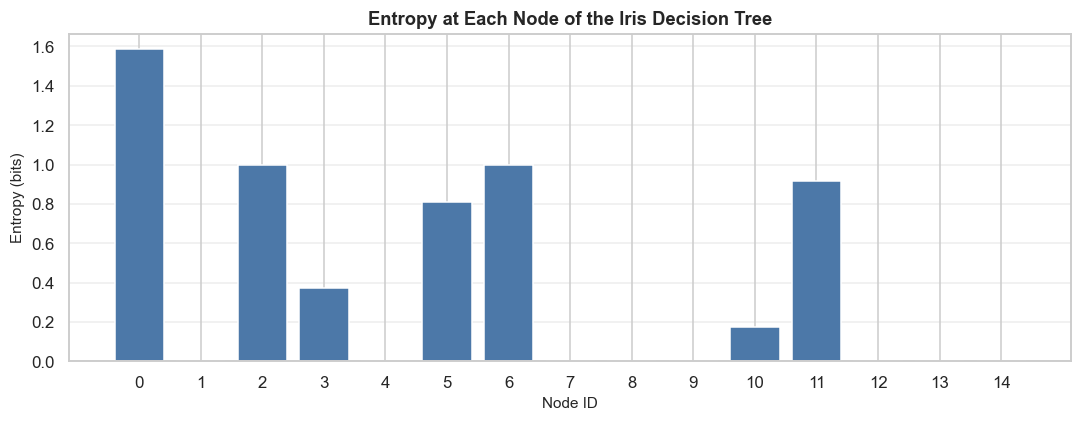

In [31]:
def plot_entropy_by_node(entropy_nodes_df):
    bar_colors = np.where(
        entropy_nodes_df["node_type"] == "leaf",
        "#9E9E9E",
        CLASS_PALETTE["setosa"],
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(
        entropy_nodes_df["node_id"],
        entropy_nodes_df["entropy_bits"],
        color=bar_colors,
    )

    ax.set_xlabel("Node ID")
    ax.set_ylabel("Entropy (bits)")
    ax.set_title("Entropy at Each Node of the Iris Decision Tree")
    ax.set_xticks(entropy_nodes_df["node_id"])
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.show()


plot_entropy_by_node(entropy_nodes_df)

The entropy bar chart visually confirms the pattern shown in the node-level summary table. The root node, node `0`, has the highest entropy value, `1.5850` bits, because it contains the full training set with an equal distribution across Setosa, Versicolor, and Virginica.

Node `2` also has high entropy, equal to `1.0000`, because it contains 80 observations split evenly between Versicolor and Virginica. This reinforces that, after Setosa is separated, the main uncertainty remains between the two non-Setosa species.

Several nodes have entropy equal to `0.0000`, including nodes `1`, `4`, `7`, `8`, `9`, `12`, `13`, and `14`. These zero-entropy nodes correspond to pure regions of the tree, where all training observations reaching the node belong to a single class. Because their entropy is zero, their bars are not visually prominent in the chart.

The chart also highlights smaller internal nodes with relatively high entropy, such as node `5` with entropy `0.8113`, node `6` with entropy `1.0000`, and node `11` with entropy `0.9183`. Based on the node summary table, these nodes contain only 4, 2, and 3 samples, respectively. Therefore, they should be interpreted as local borderline regions rather than broad patterns in the dataset.

Overall, the entropy visualization supports the same conclusion found in the decision paths and confusion matrix: the tree separates Setosa cleanly and early, while the remaining uncertainty is concentrated in small regions where Versicolor and Virginica overlap.

## 7. Conclusion and Next Steps

This notebook followed a structured machine learning workflow for the Iris classification problem, including environment setup, data loading, data quality inspection, exploratory data analysis, model training, validation, interpretability, pruning, and entropy-based diagnostics.

The exploratory analysis showed that petal length and petal width are the most informative variables for distinguishing Iris species. Across the scatter plots, boxplots, histograms, pairplot, correlation analysis, and t-SNE projection, Setosa consistently appeared as the most clearly separated class. In contrast, Versicolor and Virginica showed partial overlap, especially in the petal-based feature space.

The Decision Tree model confirmed these exploratory findings. The first split used petal length to separate Setosa from the other species, creating a pure Setosa branch. On the holdout test set, the original tree achieved an accuracy of `0.9333`, correctly classifying 28 out of 30 observations. The confusion matrix showed that all Setosa observations were classified correctly, while the only two errors occurred between Versicolor and Virginica.

Cross-validation provided a more robust estimate of performance than the single holdout split. The model achieved a mean cross-validation accuracy of `0.9533`, with fold accuracies ranging from `0.9000` to `1.0000`. This indicates strong overall performance, while also showing some variability due to the small size of the Iris dataset.

The interpretability analyses helped explain how the model reached its predictions. Decision paths showed that Setosa observations followed short paths, while more difficult Versicolor and Virginica cases required deeper routes. The entropy analysis also supported this interpretation: the root node started with maximum uncertainty, the first split created a pure Setosa node, and the remaining uncertainty was concentrated in nodes containing Versicolor and Virginica observations.

The pruning analysis showed that a simpler tree could perform comparably or slightly better than the original tree. The selected pruned tree used `ccp_alpha = 0.03264`, reduced the depth from `5` to `3`, reduced the number of leaves from `8` to `4`, and achieved a holdout accuracy of `0.9667`. Since this improvement corresponds to only one additional correct prediction in a 30-sample test set, it should be interpreted cautiously. Still, the result suggests that a simpler tree may be preferable for interpretability.

Overall, the notebook demonstrates that a Decision Tree can classify the Iris dataset with strong performance while remaining highly interpretable. The main analytical conclusion is consistent across all sections: Setosa is easily separated by petal measurements, while the main classification challenge lies in distinguishing Versicolor from Virginica.

As next steps, this analysis could be extended by comparing the Decision Tree with other classification models, such as logistic regression, k-nearest neighbors, random forests, or support vector machines. The pruning analysis could also be expanded with a more detailed validation strategy. In addition, permutation importance could be repeated under cross-validation to reduce dependence on a single holdout split.

Because the Iris dataset is a simple benchmark dataset, the main value of this notebook is not the difficulty of the prediction task itself. Its value is in demonstrating a clean machine learning workflow, careful exploratory analysis, interpretable modeling, validation discipline, and critical evaluation of model behavior.